# Immorthon

## Installation des dépendances

In [ ]:
!pip install datasets
!pip install torch
!pip install transformers
!pip install accelerate peft
#!pip install faiss-cpu # Utile que pour RAG, pas nécessaire pour le SLM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 39.1 MB/s eta 0:00:00


## Import des modules et classes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from transformers.models.auto.tokenization_auto import AutoTokenizer
from transformers.models.auto.modeling_auto import AutoModelForCausalLM
from transformers.tokenization_utils_base import BatchEncoding
from transformers.training_args import TrainingArguments
from transformers import Trainer, TrainingArguments

## Préparation de l'environnement

In [ ]:


dicoPath = "dataset.csv"

# set pandas to print full strings
pd.set_option('display.max_colwidth', None)

Archive:  model.zip
   creating: model/
  inflating: model/generation_config.json  
  inflating: model/tokenizer_config.json  
  inflating: model/tokenizer.json    
  inflating: model/model.safetensors  
  inflating: model/config.json       


## Chargement et préparation des données

In [4]:
# renvoie le dataFrame avec la colonne "text" ajoutée
def loadAndPreprocessData(dicoPath:str) -> pd.DataFrame:
    df = pd.read_csv(dicoPath, encoding="utf-8", on_bad_lines="warn", na_filter=False)
    # On ne veut pas de valeur "None"
    if df.isnull().values.any():
        raise ValueError("None values in dataframe")
    # créer la colonne sur laquelle on va entrainer le modèle
    df["text"] = df["prompt"] + "\n" + df["julia code"]
    return df

df = loadAndPreprocessData(dicoPath)

# séparer aléatoirement la data en train et test
dataset = Dataset.from_pandas(df[["prompt", "julia code"]])
splitDataset = dataset.train_test_split(test_size=0.1)

NameError: name 'dicoPath' is not defined

## Représentation des données

## Import du modèle et du tokeniseur

In [ ]:
#!unzip model.zip         # Only with a local model
# par ordre croissant de taille
modelNames = [
    "model", # modèle entrainé sur des exemples
    "gpt2",
]
modelName = modelNames[1] # choisir le modèle à utiliser (0 pour le modèle entrainé, 1 pour gpt2)

tokenizer = AutoTokenizer.from_pretrained(modelName)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.add_special_tokens({
    "eos_token": "<TOKEN_FINAL>"
})
model = AutoModelForCausalLM.from_pretrained(modelName)
model.resize_token_embeddings(len(tokenizer))


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


['á', 'º', 'ĭ', '(', 't', ')', 'Ġ==', 'Ġ[', 'v', '(', 't', '),', 'Ġu', '(', 't', ')]']
['âī', '¤']
['<', 'END', '>']
50258
50258


## Tokenisation des données d'entrainement

In [7]:
def tokenizeDataSet(dataset: DatasetDict, tokenizer: AutoTokenizer, max_length) -> DatasetDict:
    def tokenize(examples):
        prompts = examples["prompt"]
        outputs = examples["julia code"]

        full_texts = [
            p + "\n" + o
            for p, o in zip(prompts, outputs)
        ]

        tokenized = tokenizer(
            full_texts,
            truncation=True,
            padding="max_length",
            max_length=512
        )

        labels = []

        for i in range(len(prompts)):

            input_ids = tokenized["input_ids"][i]

            prompt_ids = tokenizer(
                prompts[i] + "\n",
                truncation=True,
                max_length=max_length,
                add_special_tokens=False
            )["input_ids"]

            prompt_length = len(prompt_ids)

            label = input_ids.copy()
            label[:prompt_length] = [-100] * prompt_length

            labels.append(label)

        tokenized["labels"] = labels

        return tokenized
    return dataset.map(tokenize, batched=True)

tokenizedDataset = tokenizeDataSet(splitDataset, tokenizer, 512)

NameError: name 'splitDataset' is not defined

## Entrainement

In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)


In [ ]:
trainingArgs = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=trainingArgs,
    train_dataset=tokenizedDataset["train"],
    eval_dataset=tokenizedDataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 50256}.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


## Affichage des données d'entrainement

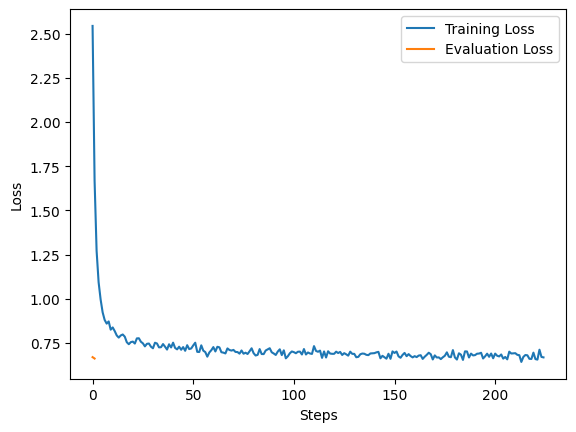

In [ ]:
logHistory = trainer.state.log_history

trainLosses = [log["loss"] for log in logHistory if "loss" in log]
evalLosses = [log["eval_loss"] for log in logHistory if "eval_loss" in log] # vide, mais jsp pk

plt.plot(trainLosses, label="Training Loss")
plt.plot(evalLosses, label="Evaluation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

## RAG (utilisation de la documentation)(Fonctionne pas)

In [ ]:
import requests
from bs4 import BeautifulSoup
import re
import json
from typing import List, Dict
import tiktoken

# ==========================
# CONFIG
# ==========================

URL = "https://control-toolbox.org/OptimalControl.jl/stable/manual-abstract.html"
MAX_TOKENS = 800
MODEL_ENCODING = "cl100k_base"  # compatible OpenAI embeddings


def count_tokens(text: str) -> int:
    enc = tiktoken.get_encoding(MODEL_ENCODING)
    return len(enc.encode(text))


def download_page(url: str) -> str:
    response = requests.get(url)
    response.raise_for_status()
    return response.text


def clean_html(html: str) -> BeautifulSoup:
    soup = BeautifulSoup(html, "html.parser")

    # Remove scripts, style, navigation
    for tag in soup(["script", "style", "nav", "footer"]):
        tag.decompose()

    return soup


def extract_sections(soup: BeautifulSoup) -> Dict[str, str]:
    sections = {}

    # Target h2/h3 as section boundaries
    headers = soup.find_all(["h2", "h3"])

    for header in headers:
        title = header.get_text(strip=True)

        content = []
        for sibling in header.next_siblings:
            if sibling.name in ["h2", "h3"]:
                break
            if sibling.name:
                content.append(sibling.get_text(" ", strip=True))

        text = "\n".join(content).strip()

        if len(text) > 50:  # avoid empty sections
            sections[title] = text

    return sections


def build_chunks(sections: Dict[str, str]) -> List[Dict]:
    chunks = []

    for title, content in sections.items():

        structured_text = f"""
[SECTION: {title.upper()}]

[CONTENT]
{content}
""".strip()

        token_count = count_tokens(structured_text)

        # If too large → split
        if token_count > MAX_TOKENS:
            sub_chunks = split_large_chunk(title, content)
            chunks.extend(sub_chunks)
        else:
            chunks.append({
                "section": title,
                "text": structured_text,
                "tokens": token_count
            })

    return chunks


def split_large_chunk(title: str, content: str) -> List[Dict]:
    paragraphs = re.split(r"\n\s*\n", content)
    current_chunk = ""
    chunks = []

    for para in paragraphs:
        temp = current_chunk + "\n\n" + para
        if count_tokens(temp) > MAX_TOKENS:
            chunks.append({
                "section": title,
                "text": f"[SECTION: {title.upper()}]\n\n{current_chunk.strip()}",
                "tokens": count_tokens(current_chunk)
            })
            current_chunk = para
        else:
            current_chunk = temp

    if current_chunk:
        chunks.append({
            "section": title,
            "text": f"[SECTION: {title.upper()}]\n\n{current_chunk.strip()}",
            "tokens": count_tokens(current_chunk)
        })

    return chunks


def save_chunks(chunks: List[Dict], filename="dsl_chunks.json"):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(chunks, f, indent=2, ensure_ascii=False)


def main():
    print("Downloading page...")
    html = download_page(URL)

    print("Cleaning HTML...")
    soup = clean_html(html)

    print("Extracting sections...")
    sections = extract_sections(soup)

    print("Building chunks...")
    chunks = build_chunks(sections)

    print(f"Generated {len(chunks)} chunks.")
    print("Saving...")
    save_chunks(chunks)

    print("Done ✔")


if __name__ == "__main__":
    main()

Cleaning HTML...
Extracting sections...
Building chunks...
Generated 13 chunks.
Saving...
Done ✔


In [ ]:
import json

with open("dsl_chunks.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

texts = [c["text"] for c in chunks]

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(texts, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

In [ ]:
def retrieve(query, k=3):
    query_embedding = embedding_model.encode([query])
    distances, indices = index.search(np.array(query_embedding), k)

    results = []
    for i in indices[0]:
        results.append(texts[i])

    return results

In [ ]:
def build_prompt(user_query):
    retrieved_chunks = retrieve(user_query, k=12)

    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
You are an expert in OptimalControl.jl DSL.

Use the documentation below ONLY as reference.
Do not copy grammar templates.
Generate a complete and valid DSL instance.

Your output must start with:
@def begin

### Documentation
{context}

### Task
Translate the following problem into DSL:

{user_query}

###DSL:
"""
    return prompt

## Utilisation du modèle

In [ ]:
from transformers.pipelines import pipeline

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

def generate(prompt):
    fullPrompt = f"{prompt}\n"
    results = generator(fullPrompt, max_length=512, num_return_sequences=1, do_sample=True, temperature=0.7, truncation=True)
    return [result["generated_text"] for result in results]
# Utile seulement pour le RAG
# query = """minimise the final time tf
# under the constraint q''(t) = u(t)
# with -1 <= u(t) <= 1, q(0) = 1, q'(0) = -2, q(tf) = 3, q'(tf) = 1, and q'(t) <= 1."""
# prompt = build_prompt(query)

prompt = """###Prompt
Translate the following problem into DSL:

minimise tf
# Variable: tf
# State: s, q, v
# Control: u
# Dynamics
q'(t) = v(t)
v'(t) = u(t)
# Initial Conditions
v(0) = -2
q(0) = 1,
# Final Conditions
q(tf) = 3
v(tf) = 1,
# State Constraints
v(t) <= 1,
# Variable Constraints
,
# Control Constraints
-1 <= u(t) <= 1
"""

rep = generate(prompt)
code = rep[0][len(prompt):len(rep[0])]

print(code)

with open("code.jl", "w", encoding="utf-8") as f:
    f.write(code)


Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




###DSL:
h0 = 1
v0 = 0
m0 = 1
mf = 0
hc = 500
g0 = 1
mf = mc*m0
Tc = 3
5
mc = 0
6 = 1
mf = mc*m0
Tc = 3


@def begin
    tf ∈ R, variable
    t ∈ [0, tf], time
    s = (h, v, m) ∈ R³, state
    u ∈ R, control

    # Dynamics
    ∂(h)(t) == v(t)
    ∂(v)(t) == (T(t) - D(h(t)) - m(t) * g(h(h(t)) / m(t)
    ∂(m)(t) == -T(t) / c

    # Initial Conditions
    h(0) == h0
    v(0) == v0
    m(0) == m0

  


## Enregistrement et téléchargement du modèle entrainé

In [ ]:
from google.colab import files
# enregistrer le modèle
model.save_pretrained("model")
tokenizer.save_pretrained("model")
# zipper le modèle
!zip -r model.zip model

# télécharger le zip
files.download("model.zip")

NameError: name 'model' is not defined